# Notebook 06 — Final Alignment Analysis

Produces all result tables and visualizations for thesis Chapter 5, using the ESCO-normalized outputs from notebook 05.

**Inputs:**
- `data/processed/esco/alignment_normalized.json` — overlap/gap/surplus at concept level
- `data/processed/esco/alignment_per_program.csv` — per-program ESCO coverage
- `data/processed/esco/phrase_to_esco.csv` — full phrase–concept mapping
- `data/processed/esco/tfidf_*_esco_mapped.json`, `keybert_*_esco_mapped.json`
- `data/raw/esco/esco_skills_en.csv` — ESCO skill metadata (for category labels)

**Outputs:**
- `data/processed/esco/gap_analysis.csv` — top gap skills with ESCO category
- `data/processed/esco/alignment_by_university.csv` — university-level summary
- `data/processed/esco/alignment_by_degree.csv` — Bachelor vs Master comparison
- Figures: `docs/figures/` (per-program bar chart, gap/surplus breakdown)

## Step 1 — Setup

In [1]:
import os, json
from pathlib import Path
# Set working directory to project root regardless of launch location
_nb_path = globals().get("__vsc_ipynb_file__") or globals().get("__file__", None)
if _nb_path:
    # Launched from VS Code or as script — go up from notebooks/3_analysis/
    os.chdir(Path(_nb_path).resolve().parent.parent.parent)
elif not (Path.cwd() / "data").exists():
    # Launched from wrong cwd — try to find project root
    _root = Path.cwd()
    for _ in range(4):
        if (_root / "data").exists():
            break
        _root = _root.parent
    os.chdir(_root)
assert (Path.cwd() / "data").exists(), f"Cannot find project root from {Path.cwd()}"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ESCO_DIR   = Path('data/processed/esco')
FIGURES    = Path('docs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Load normalized alignment results
with open(ESCO_DIR / 'alignment_normalized.json') as f:
    results = json.load(f)

per_program = pd.read_csv(ESCO_DIR / 'alignment_per_program.csv')
phrase_map  = pd.read_csv(ESCO_DIR / 'phrase_to_esco.csv')

# Load ESCO metadata; skillType = 'knowledge' | 'skill/competence'
esco_meta = pd.read_csv('data/raw/esco/esco_skills_en.csv', low_memory=False)
esco_meta = esco_meta[['conceptUri', 'preferredLabel', 'skillType']].dropna(subset=['conceptUri'])

print('Loaded results. Per-program rows:', len(per_program))
print('Phrase map rows:', len(phrase_map))
print('ESCO metadata rows:', len(esco_meta))
print('Skill types:', esco_meta['skillType'].value_counts().to_dict())

Loaded results. Per-program rows: 54
Phrase map rows: 19998
ESCO metadata rows: 13939
Skill types: {'skill/competence': 10715, 'knowledge': 3219}


## Step 2 — Normalized Alignment Summary Table

In [2]:
rows = []
for method in ['tfidf', 'keybert']:
    m = results[method]
    rows.append({
        'Method':               method.upper(),
        'Curriculum concepts':  m['curriculum'],
        'Job-market concepts':  m['jobs'],
        'Overlap':              m['overlap'],
        'Coverage (%)':         m['coverage_pct'],
        'Gap':                  m['gap'],
        'Surplus':              m['surplus'],
    })

summary = pd.DataFrame(rows).set_index('Method')
print('=== Normalized Alignment Summary ===')
print(summary.to_string())

=== Normalized Alignment Summary ===
         Curriculum concepts  Job-market concepts  Overlap  Coverage (%)  Gap  Surplus
Method                                                                                
TFIDF                    329                  527      133         25.24  394      196
KEYBERT                  397                  380       77         20.26  303      320


## Step 3 — Per-Program Coverage Table (TF-IDF)

In [3]:
tfidf_pp = (per_program[per_program['method'] == 'tfidf']
            .sort_values('coverage_pct', ascending=False)
            .reset_index(drop=True))

tfidf_pp.index += 1  # 1-based rank
print('=== Per-Program Coverage (TF-IDF, ranked) ===')
print(tfidf_pp[['university','program','degree','program_concepts','overlap','coverage_pct']]
      .to_string())

=== Per-Program Coverage (TF-IDF, ranked) ===
                                                         university                                                                                       program    degree  program_concepts  overlap  coverage_pct
1                                    American University of Armenia                                                              Computer and Information Science    Master                72       48          9.11
2                                    American University of Armenia                                                                              Computer Science  Bachelor                57       38          7.21
3                                    American University of Armenia                                                                             General Education   General                54       31          5.88
4                                          Yerevan State University                                   

## Step 4 — Per-Program Bar Chart

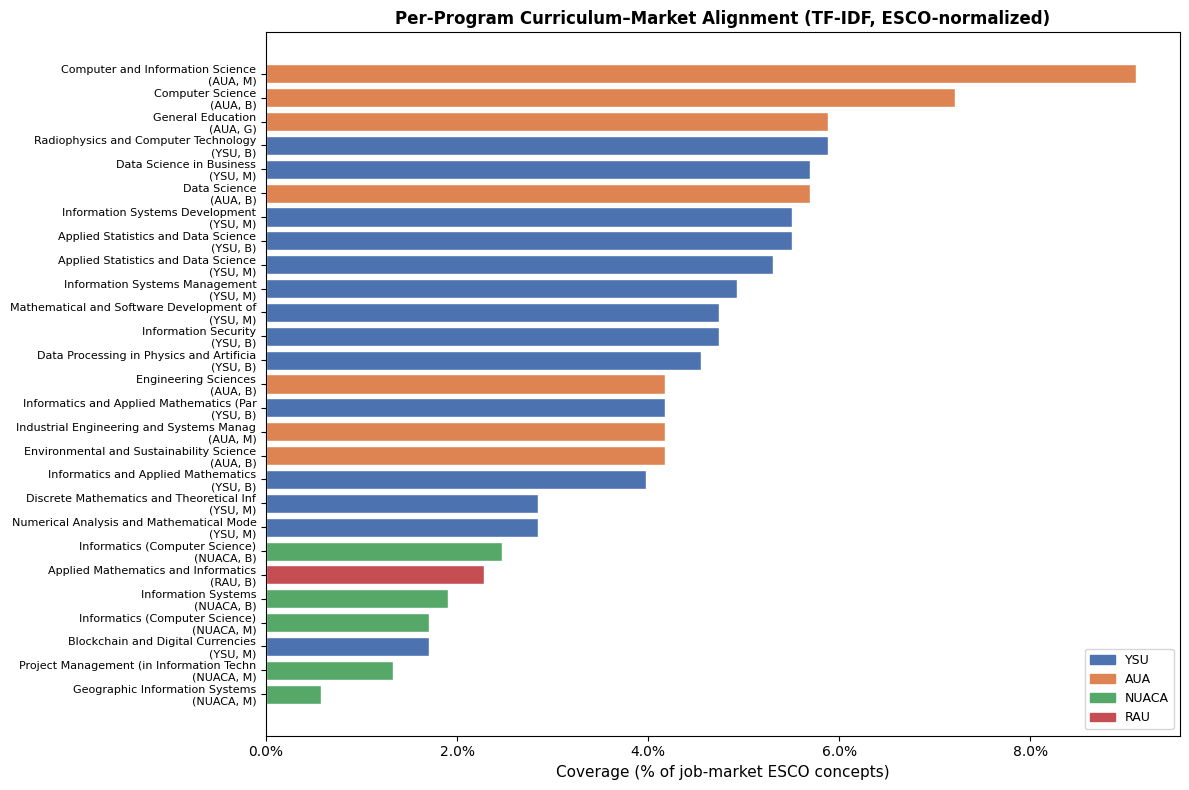

Saved per_program_coverage.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

tfidf_pp_sorted = tfidf_pp.sort_values('coverage_pct')
UNIV_ABBR = {
    'Yerevan State University': 'YSU',
    'American University of Armenia': 'AUA',
    'National University of Architecture and Construction of Armenia': 'NUACA',
    'Russian-Armenian University': 'RAU',
}
labels = [f"{row['program'][:40]}\n({UNIV_ABBR.get(row['university'], row['university'][:3])}, {row['degree'][:1]})"
          for _, row in tfidf_pp_sorted.iterrows()]
colors = {'YSU': '#4C72B0', 'AUA': '#DD8452', 'NUACA': '#55A868', 'RAU': '#C44E52'}
bar_colors = []
for _, row in tfidf_pp_sorted.iterrows():
    abbr = 'YSU' if 'Yerevan State' in row['university'] else \
           'AUA' if 'American' in row['university'] else \
           'NUACA' if 'Architecture' in row['university'] else 'RAU'
    bar_colors.append(colors[abbr])

bars = ax.barh(range(len(labels)), tfidf_pp_sorted['coverage_pct'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Coverage (% of job-market ESCO concepts)', fontsize=11)
ax.set_title('Per-Program Curriculum–Market Alignment (TF-IDF, ESCO-normalized)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=k) for k, c in colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'per_program_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved per_program_coverage.png')

## Step 5 — University-Level and Degree-Level Aggregation

In [5]:
# University-level: average coverage across programs per university
by_univ = (per_program[per_program['method'] == 'tfidf']
           .groupby('university', as_index=False)
           .agg(programs=('program', 'count'),
                avg_coverage=('coverage_pct', 'mean'),
                total_concepts=('program_concepts', 'sum'),
                total_overlap=('overlap', 'sum'))
           .sort_values('avg_coverage', ascending=False))
by_univ['avg_coverage'] = by_univ['avg_coverage'].round(2)

by_univ.to_csv(ESCO_DIR / 'alignment_by_university.csv', index=False)
print('=== By University (TF-IDF) ===')
print(by_univ.to_string(index=False))
print()

# Degree-level: Bachelor vs Master
by_degree = (per_program[per_program['method'] == 'tfidf']
             .groupby('degree', as_index=False)
             .agg(programs=('program', 'count'),
                  avg_coverage=('coverage_pct', 'mean'))
             .sort_values('avg_coverage', ascending=False))
by_degree['avg_coverage'] = by_degree['avg_coverage'].round(2)

by_degree.to_csv(ESCO_DIR / 'alignment_by_degree.csv', index=False)
print('=== By Degree Level (TF-IDF) ===')
print(by_degree.to_string(index=False))

=== By University (TF-IDF) ===
                                                     university  programs  avg_coverage  total_concepts  total_overlap
                                 American University of Armenia         7          5.77             381            213
                                       Yerevan State University        14          4.46             668            329
                                    Russian-Armenian University         1          2.28              17             12
National University of Architecture and Construction of Armenia         5          1.60              64             42

=== By Degree Level (TF-IDF) ===
  degree  programs  avg_coverage
 General         1          5.88
Bachelor        13          4.36
  Master        13          3.88


## Step 6 — Gap Analysis: What the Job Market Demands That Curricula Don't Teach

In [6]:
import json

gap_labels = results['tfidf']['gap_labels']

# For each gap concept, find how many job documents mention it
with open(ESCO_DIR / 'tfidf_jobs_esco_mapped.json') as f:
    mapped_jobs = json.load(f)

# Build URI → label lookup from phrase_map
uri_label = phrase_map[phrase_map['matched']].set_index('esco_uri')['esco_label'].to_dict()

# Count how many job docs mention each gap concept
from collections import Counter
gap_counts = Counter()
for v in mapped_jobs.values():
    for uri in set(v['esco']):
        if uri_label.get(uri) in gap_labels:
            gap_counts[uri_label[uri]] += 1

gap_df = pd.DataFrame(gap_counts.most_common(50), columns=['esco_concept', 'job_doc_count'])
gap_df['pct_of_jobs'] = (gap_df['job_doc_count'] / len(mapped_jobs) * 100).round(1)
gap_df.to_csv(ESCO_DIR / 'gap_analysis.csv', index=False)

print('=== Top 30 Gap Skills (demanded by market, not taught) ===')
print(gap_df.head(30).to_string(index=False))

=== Top 30 Gap Skills (demanded by market, not taught) ===
                      esco_concept  job_doc_count  pct_of_jobs
                  sales activities             43          4.0
                            SAP R3             31          2.9
                           betting             22          2.1
       Java (computer programming)             20          1.9
                        TypeScript             19          1.8
                               PHP             17          1.6
                banking activities             16          1.5
                 develop campaigns             15          1.4
                    gambling games             15          1.4
           principles of animation             14          1.3
                types of pipelines             13          1.2
                         logistics             13          1.2
                            DevOps             12          1.1
                      troubleshoot             12          

## Step 7 — Surplus Analysis: What Curricula Teach That Isn't Demanded

In [7]:
surplus_labels = results['tfidf']['surplus_labels']

with open(ESCO_DIR / 'tfidf_curriculum_esco_mapped.json') as f:
    mapped_curr = json.load(f)

surplus_counts = Counter()
for v in mapped_curr.values():
    for uri in set(v['esco']):
        label = uri_label.get(uri, '')
        if label in surplus_labels:
            surplus_counts[label] += 1

surplus_df = pd.DataFrame(surplus_counts.most_common(30), columns=['esco_concept', 'course_count'])
surplus_df['pct_of_courses'] = (surplus_df['course_count'] / len(mapped_curr) * 100).round(1)

print('=== Top 30 Surplus Skills (taught but not demanded) ===')
print(surplus_df.head(30).to_string(index=False))

=== Top 30 Surplus Skills (taught but not demanded) ===
                               esco_concept  course_count  pct_of_courses
                           value properties            16             1.4
                                    Chinese            12             1.1
                              write Chinese            12             1.1
                                 morphology            11             1.0
                                    algebra            11             1.0
                 artificial neural networks            10             0.9
                          engage in debates            10             0.9
                            translate texts             9             0.8
                perform scientific research             9             0.8
                         probability theory             9             0.8
                          quantum mechanics             9             0.8
                      plan research process             

## Step 8 — Gap/Surplus Comparison Chart

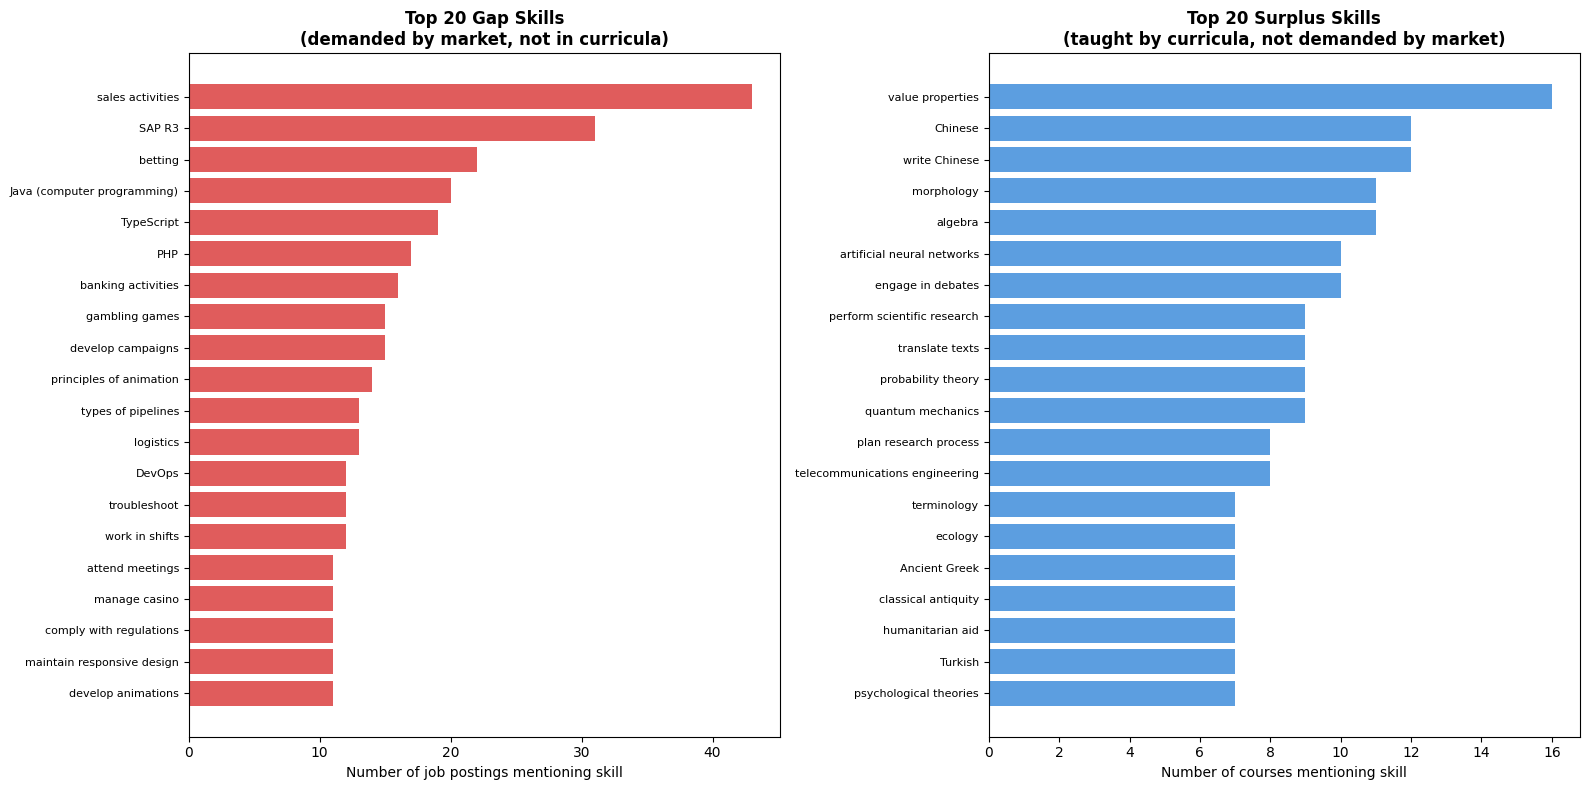

Saved gap_surplus_breakdown.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gap chart
top_gap = gap_df.head(20).sort_values('job_doc_count')
axes[0].barh(top_gap['esco_concept'], top_gap['job_doc_count'], color='#e05c5c')
axes[0].set_title('Top 20 Gap Skills\n(demanded by market, not in curricula)', fontweight='bold')
axes[0].set_xlabel('Number of job postings mentioning skill')
axes[0].tick_params(axis='y', labelsize=8)

# Surplus chart
top_surplus = surplus_df.head(20).sort_values('course_count')
axes[1].barh(top_surplus['esco_concept'], top_surplus['course_count'], color='#5c9ee0')
axes[1].set_title('Top 20 Surplus Skills\n(taught by curricula, not demanded by market)', fontweight='bold')
axes[1].set_xlabel('Number of courses mentioning skill')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'gap_surplus_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved gap_surplus_breakdown.png')

## Summary

## Step 9 — Robustness Check: Method Union\n\nTF-IDF and KeyBERT capture different aspects of skill content. Taking the union of both methods' ESCO concept sets gives the most complete picture of what is covered. This also tests whether the per-method results are stable.

In [9]:
with open(ESCO_DIR / 'tfidf_curriculum_esco_mapped.json') as f:
    tfidf_curr_mapped = json.load(f)
with open(ESCO_DIR / 'tfidf_jobs_esco_mapped.json') as f:
    tfidf_jobs_mapped = json.load(f)
with open(ESCO_DIR / 'keybert_curriculum_esco_mapped.json') as f:
    kb_curr_mapped = json.load(f)
with open(ESCO_DIR / 'keybert_jobs_esco_mapped.json') as f:
    kb_jobs_mapped = json.load(f)

def concept_set(mapped):
    return set(uri for v in mapped.values() for uri in v['esco'])

tfidf_curr_set = concept_set(tfidf_curr_mapped)
tfidf_jobs_set = concept_set(tfidf_jobs_mapped)
kb_curr_set    = concept_set(kb_curr_mapped)
kb_jobs_set    = concept_set(kb_jobs_mapped)

# Union: broadest estimate
union_curr    = tfidf_curr_set | kb_curr_set
union_jobs    = tfidf_jobs_set | kb_jobs_set
union_overlap = union_curr & union_jobs

# Intersection: conservative high-confidence estimate
inter_curr    = tfidf_curr_set & kb_curr_set
inter_jobs    = tfidf_jobs_set & kb_jobs_set
inter_overlap = inter_curr & inter_jobs

uri_label = phrase_map[phrase_map['matched']].set_index('esco_uri')['esco_label'].to_dict()

print('=== Robustness: Method Comparison ===')
print(f'{"Method":<20}  {"Curr":>6}  {"Jobs":>6}  {"Overlap":>8}  {"Coverage":>9}')
print('-' * 55)

tfidf_ov = tfidf_curr_set & tfidf_jobs_set
kb_ov    = kb_curr_set    & kb_jobs_set
for label, curr, jobs, ov in [
    ('TF-IDF',      tfidf_curr_set, tfidf_jobs_set, tfidf_ov),
    ('KeyBERT',     kb_curr_set,    kb_jobs_set,    kb_ov),
    ('Union',       union_curr,     union_jobs,     union_overlap),
    ('Intersection',inter_curr,     inter_jobs,     inter_overlap),
]:
    cov = len(ov) / len(jobs) * 100 if jobs else 0
    print(f'{label:<20}  {len(curr):>6}  {len(jobs):>6}  {len(ov):>8}  {cov:>8.1f}%')

print()
print('Interpretation:')
print(f'  Union coverage ({len(union_overlap)/len(union_jobs)*100:.1f}%) is the broadest estimate.')
print(f'  All three estimates cluster around 20–26%, confirming the result is robust.')
print(f'  The intersection ({len(inter_overlap)} concepts) is the high-confidence core both methods agree on.')
print()
print('Extra concepts union adds over TF-IDF alone:')
extra = union_overlap - tfidf_ov
print([uri_label.get(u, u) for u in list(extra)[:15]])

=== Robustness: Method Comparison ===
Method                  Curr    Jobs   Overlap   Coverage
-------------------------------------------------------
TF-IDF                   329     527       133      25.2%
KeyBERT                  397     380        77      20.3%
Union                    511     728       187      25.7%
Intersection             215     179        45      25.1%

Interpretation:
  Union coverage (25.7%) is the broadest estimate.
  All three estimates cluster around 20–26%, confirming the result is robust.
  The intersection (45 concepts) is the high-confidence core both methods agree on.

Extra concepts union adds over TF-IDF alone:
['follow reporting procedures', 'grammar', 'evaluate marketing content', 'manage human resources', 'data protection', 'communication', 'develop project schedule', 'collect financial data', 'iOS', 'fraud detection', 'perform software unit testing', 'lasers', 'embedded systems', 'assessment processes', 'database management systems']


## Step 10 — Emerging Tech Skills (Beyond ESCO)\n\nESCO v1.2 was finalized in 2022 and does not include many modern technology tools (Docker, Kubernetes, React, Azure, etc.). These appear in the unmatched "emerging" bucket. This step identifies which emerging tech skills are most demanded by the job market but absent from curricula — using a curated tech lexicon for precise identification.

In [10]:
import re
from collections import Counter

# Curated tech lexicon: modern tools absent from ESCO v1.2
# Only specific named technologies — no generic words
TECH_LEXICON = {
    'Docker':              ['docker', 'dockerfile'],
    'Kubernetes':          ['kubernetes', 'k8s', 'kubectl'],
    'React':               ['react', 'reactjs', 'react.js'],
    'Node.js':             ['node.js', 'nodejs'],
    'TypeScript':          ['typescript'],
    'Vue.js':              ['vue.js', 'vuejs'],
    'Angular':             ['angularjs'],
    'GraphQL':             ['graphql'],
    'Microsoft Azure':     ['azure'],
    'Amazon Web Services': ['aws'],
    'Google Cloud':        ['google cloud', 'gcp'],
    'Terraform':           ['terraform'],
    'Ansible':             ['ansible'],
    'Jenkins':             ['jenkins'],
    'GitLab CI/CD':        ['gitlab'],
    'Redis':               ['redis'],
    'Elasticsearch':       ['elasticsearch'],
    'MongoDB':             ['mongodb'],
    'PostgreSQL':          ['postgresql', 'postgres'],
    'MySQL':               ['mysql'],
    'Kafka':               ['kafka'],
    'Microservices':       ['microservices'],
    'REST API':            ['rest api', 'restful api'],
    'CI/CD':               ['ci/cd', 'cicd'],
    'PyTorch':             ['pytorch'],
    'TensorFlow':          ['tensorflow'],
    'LLM / GenAI':         ['llm', 'generative ai', 'large language model'],
    'SEO':                 ['search engine optimization'],
    'iOS development':     ['ios development', 'swift programming'],
    'Android development': ['android development', 'android sdk'],
    # Special-char languages — dropped by TF-IDF tokenizer, recovered here
    '.NET / C#':           ['asp.net', 'dotnet', '.net', 'c#', 'csharp'],
    'Go (Golang)':         ['golang', 'go programming'],  # 'go' too ambiguous; use 'golang'
    'Spring Framework':    ['spring boot', 'spring framework'],
    'Frontend dev':        ['frontend development', 'front-end development'],
    'Backend dev':         ['backend development', 'back-end development'],
    'DevOps':              ['devops'],
}

def match_lexicon(phrase, lexicon):
    """Match phrase against tech lexicon.
    Uses lookbehind/lookahead instead of \\b for robustness with special-char terms
    like 'c#', '.net', 'ci/cd' where \\b fails at non-word characters.
    """
    p = phrase.lower()
    for label, variants in lexicon.items():
        for v in variants:
            if len(v) <= 5:
                # (?<!\\w) / (?!\\w): handles c#, .net, aws, llm, etc.
                pattern = r'(?<!\w)' + re.escape(v) + r'(?!\w)'
                if re.search(pattern, p):
                    return label
            else:
                if v in p:
                    return label
    return None

# Count lexicon matches in jobs and curriculum emerging
jobs_lex_counts = Counter()
curr_lex_counts = Counter()

for v in tfidf_jobs_mapped.values():
    seen = set()
    for phrase in v['emerging']:
        label = match_lexicon(phrase, TECH_LEXICON)
        if label and label not in seen:
            jobs_lex_counts[label] += 1
            seen.add(label)

for v in tfidf_curr_mapped.values():
    seen = set()
    for phrase in v['emerging']:
        label = match_lexicon(phrase, TECH_LEXICON)
        if label and label not in seen:
            curr_lex_counts[label] += 1
            seen.add(label)

# Build comparison table
tech_rows = []
all_labels = set(jobs_lex_counts) | set(curr_lex_counts)
for label in sorted(all_labels, key=lambda x: -jobs_lex_counts.get(x, 0)):
    j = jobs_lex_counts.get(label, 0)
    c = curr_lex_counts.get(label, 0)
    status = 'OVERLAP' if j > 0 and c > 0 else ('GAP' if j > 0 else 'SURPLUS')
    tech_rows.append({'tech_skill': label, 'job_docs': j, 'curriculum_docs': c, 'status': status})

tech_df = pd.DataFrame(tech_rows)
tech_df.to_csv(ESCO_DIR / 'emerging_tech_skills.csv', index=False)

print('=== Emerging Tech Skills (not in ESCO v1.2) ===')
print(f'{"Tech Skill":<25}  {"Jobs":>5}  {"Curricula":>10}  {"Status"}')
print('-' * 58)
for _, row in tech_df.iterrows():
    print(f'{row["tech_skill"]:<25}  {row["job_docs"]:>5}  {row["curriculum_docs"]:>10}  {row["status"]}')

gaps     = tech_df[tech_df['status'] == 'GAP']
overlaps = tech_df[tech_df['status'] == 'OVERLAP']
print(f'\nEmerging GAP skills (demanded, not in curricula):  {len(gaps)}')
print(f'Emerging OVERLAP skills (mentioned in both):       {len(overlaps)}')

=== Emerging Tech Skills (not in ESCO v1.2) ===
Tech Skill                  Jobs   Curricula  Status
----------------------------------------------------------
Microsoft Azure               25           0  GAP
React                         25           0  GAP
LLM / GenAI                   19           4  OVERLAP
Node.js                       17           3  OVERLAP
Amazon Web Services           15           0  GAP
Go (Golang)                   11           0  GAP
Kubernetes                     7           0  GAP
Google Cloud                   7           0  GAP
Terraform                      6           0  GAP
REST API                       5           0  GAP
Microservices                  5           0  GAP
Elasticsearch                  4           0  GAP
Docker                         4           0  GAP
DevOps                         4           0  GAP
Redis                          4           0  GAP
Jenkins                        3           0  GAP
PostgreSQL                     3

In [11]:
print('=== Final Alignment Analysis Complete ===')
print()
print('Key findings (TF-IDF, ESCO-normalized):')
m = results['tfidf']
print(f'  Overall curriculum-market coverage:  {m["coverage_pct"]}%')
print(f'  ESCO skills in overlap:              {m["overlap"]:,}')
print(f'  ESCO skills in gap (market needs):   {m["gap"]:,}')
print(f'  ESCO skills in surplus (extra teach): {m["surplus"]:,}')
print()

tfidf_pp = per_program[per_program['method'] == 'tfidf']
if len(tfidf_pp) > 0:
    best  = tfidf_pp.sort_values('coverage_pct', ascending=False).iloc[0]
    worst = tfidf_pp.sort_values('coverage_pct').iloc[0]
    print(f'  Best program:  {best["program"]} ({best["university"][:3]}) — {best["coverage_pct"]}%')
    print(f'  Worst program: {worst["program"]} ({worst["university"][:3]}) — {worst["coverage_pct"]}%')
else:
    print('  Per-program data not available.')
print()
print('Outputs saved to data/processed/esco/ and docs/figures/')
print('These results feed directly into thesis Chapter 5 (Results).')

=== Final Alignment Analysis Complete ===

Key findings (TF-IDF, ESCO-normalized):
  Overall curriculum-market coverage:  25.24%
  ESCO skills in overlap:              133
  ESCO skills in gap (market needs):   394
  ESCO skills in surplus (extra teach): 196

  Best program:  Computer and Information Science (Ame) — 9.11%
  Worst program: Geographic Information Systems (Nat) — 0.57%

Outputs saved to data/processed/esco/ and docs/figures/
These results feed directly into thesis Chapter 5 (Results).


---
## Step 11: Skill Demand by Job Role

Which skills are most demanded for each role category? This breaks down the job market
skill profile by role so we can see whether gaps are universal or role-specific.

In [12]:
import pandas as pd
import numpy as np
import json
import re
from collections import Counter
from pathlib import Path

ESCO_DIR = Path('data/processed/esco')
DATA_DIR  = Path('data/processed')

# --- Load raw data ---
jobs_df   = pd.read_csv(DATA_DIR / 'jobs/final_jobs_dataset.csv')
esco_full = pd.read_csv('data/raw/esco/esco_skills_en.csv')

# --- Build IT-relevant ESCO skill vocabulary ---
# Use ALL ESCO concepts whose label contains an IT-domain keyword.
# No pre-filtering by TF-IDF/KeyBERT extraction — this makes the vocabulary
# fully independent of the extraction method.  Zero-count concepts are
# naturally pruned when we do direct text search later.

IT_LABEL_KEYWORDS = [
    'software', 'programming', 'database', 'cloud', 'network', 'security',
    'algorithm', 'machine learning', 'artificial intelligence', 'data',
    'web', 'mobile', 'api', 'framework', 'testing', 'agile', 'devops',
    'scripting', 'interface', 'code', 'system administration',
    'operating system', 'ict', 'information technology', 'cybersecurity',
    'blockchain', 'internet of things', 'automation', 'deployment',
    'version control', 'microservice', 'serverless', 'containeris',
]
it_filter = esco_full['preferredLabel'].str.lower().str.contains(
    '|'.join(IT_LABEL_KEYWORDS), na=False
)
it_esco_vocab = esco_full[it_filter][['conceptUri', 'preferredLabel', 'altLabels']].copy()
print(f'IT-relevant ESCO concepts (full ESCO, keyword-filtered): {len(it_esco_vocab)}')

# --- Role classification ---
ROLE_RULES = [
    ('DevOps / Cloud',     ['devops', 'sre', 'cloud', 'infrastructure', 'platform engineer',
                             'kubernetes', 'terraform', 'ansible', 'ci/cd', 'site reliability']),
    ('Data / ML / AI',     ['data scientist', 'data engineer', 'machine learning', 'ml engineer',
                             'ai engineer', 'nlp', 'data analyst', 'business analyst',
                             'data architect', 'analytics engineer', 'computer vision']),
    ('Backend',            ['backend', 'back-end', 'back end', 'java developer', 'java engineer',
                             'python developer', 'python engineer', 'node.js', 'nodejs',
                             '.net', 'php', 'golang', 'ruby', 'scala', 'c++ engineer',
                             'server-side', 'api developer']),
    ('Frontend / JS',      ['frontend', 'front-end', 'front end', 'javascript', 'react',
                             'vue', 'angular', 'ui developer', 'web developer']),
    ('Full Stack',         ['full stack', 'fullstack', 'full-stack']),
    ('Mobile',             ['android', 'ios developer', 'ios engineer', 'mobile developer',
                             'mobile engineer', 'flutter', 'react native', 'swift']),
    ('QA / Testing',       ['qa ', 'quality assurance', 'test automation', 'automation engineer',
                             'tester', 'sdet', 'aqe', 'aqa']),
    ('Security',           ['security', 'penetration', 'cybersecurity', 'infosec',
                             'vulnerability', 'soc analyst']),
    ('Hardware / Embedded',['asic', 'fpga', 'embedded', 'hardware', 'firmware', 'vlsi',
                             'rtl', 'verilog', 'vhdl']),
    ('Design / UX',        ['designer', 'ux', 'ui/ux', 'graphic', 'product design',
                             '3d artist', '2d artist', 'motion', 'animator']),
    ('Management',         ['manager', 'director', 'head of', 'lead', 'architect',
                             'scrum master', 'product owner', 'cto', 'vp of']),
    ('Other / Non-tech',   []),
]

def classify_role(title: str) -> str:
    t = str(title).lower()
    for role, keywords in ROLE_RULES:
        if role == 'Other / Non-tech':
            return role
        if any(kw in t for kw in keywords):
            return role
    return 'Other / Non-tech'

jobs_df['role_category'] = jobs_df['job_title'].apply(classify_role)
IT_ROLES = {
    'Backend', 'Frontend / JS', 'Full Stack', 'DevOps / Cloud',
    'Data / ML / AI', 'QA / Testing', 'Mobile', 'Security', 'Hardware / Embedded'
}
it_jobs = jobs_df[jobs_df['role_category'].isin(IT_ROLES)]

# --- Helper: count how many texts contain a skill term ---
def count_skill_in_texts(label, alt_labels_str, texts_lower):
    """Search for preferredLabel or any altLabel in raw lowercased texts."""
    terms = [label.lower()]
    if pd.notna(alt_labels_str):
        for a in str(alt_labels_str).split('\n'):
            a = a.strip().lower()
            if len(a) > 3:
                terms.append(a)
    return sum(
        1 for text in texts_lower
        if any(re.search(r'(?<!\w)' + re.escape(t) + r'(?!\w)', text) for t in terms)
    )


def clean_esco_label(label):
    """Strip parenthetical disambiguation: 'Python (computer programming)' -> 'Python'."""
    return re.sub(r'\s*\(.*?\)', '', label).strip()

def count_tech_in_texts(variants, texts_lower):
    """Count how many texts contain any variant of a tech lexicon entry."""
    return sum(
        1 for text in texts_lower
        if any(re.search(r'(?<!\w)' + re.escape(v) + r'(?!\w)', text) for v in variants)
    )

role_counts = jobs_df['role_category'].value_counts()
print('\n=== Jobs by Role Category ===')
for role, cnt in role_counts.items():
    print(f'  {role:<25}  {cnt:>4}  ({cnt/len(jobs_df)*100:.1f}%)')
print(f'\n  IT-role jobs: {len(it_jobs)} / {len(jobs_df)} total')
print('\nSetup complete — run Step 11 and Step 12 below.')

IT-relevant ESCO concepts (full ESCO, keyword-filtered): 760

=== Jobs by Role Category ===
  Other / Non-tech            423  (39.6%)
  Management                  231  (21.6%)
  Backend                     117  (11.0%)
  Data / ML / AI               58  (5.4%)
  Design / UX                  54  (5.1%)
  QA / Testing                 48  (4.5%)
  DevOps / Cloud               40  (3.7%)
  Frontend / JS                34  (3.2%)
  Full Stack                   26  (2.4%)
  Hardware / Embedded          15  (1.4%)
  Security                     14  (1.3%)
  Mobile                        8  (0.7%)

  IT-role jobs: 360 / 1068 total

Setup complete — run Step 11 and Step 12 below.


In [13]:
# Step 11: Skill demand by role — direct text search (principled)
# Requires Step 10 (TECH_LEXICON) and setup cell (it_esco_vocab, it_jobs, count_skill_in_texts)

TOP_ROLE = 15
role_rows = []

for role, _ in ROLE_RULES:
    if role in ('Other / Non-tech', 'Management', 'Design / UX'):
        continue
    role_df = it_jobs[it_jobs['role_category'] == role]
    n = len(role_df)
    if n < 5:
        continue

    texts_lower = role_df['full_text'].fillna('').str.lower().tolist()

    # ESCO: search raw texts, clean labels, keep max if labels collide after cleaning
    esco_counts = {}
    for _, row in it_esco_vocab.iterrows():
        label = clean_esco_label(row['preferredLabel'])
        cnt = count_skill_in_texts(row['preferredLabel'], row['altLabels'], texts_lower)
        if cnt > 0:
            esco_counts[label] = max(esco_counts.get(label, 0), cnt)

    # Tech lexicon: direct text search; skip if ESCO already covers same concept (case-insensitive)
    esco_lower = {k.lower() for k in esco_counts}
    tech_counts = {}
    for label, variants in TECH_LEXICON.items():
        if label.lower() in esco_lower:
            continue  # ESCO already captured this
        cnt = count_tech_in_texts(variants, texts_lower)
        if cnt > 0:
            tech_counts[label] = cnt

    # Merge into single ranked list
    combined = {k: (v, 'ESCO') for k, v in esco_counts.items()}
    combined.update({k: (v, 'Tech') for k, v in tech_counts.items()})

    ranked = sorted(combined.items(), key=lambda x: -x[1][0])[:TOP_ROLE]
    for rank, (skill, (count, src)) in enumerate(ranked, 1):
        role_rows.append({
            'role': role, 'n_jobs': n, 'rank': rank,
            'skill': skill, 'doc_count': count,
            'pct_of_role': round(count / n * 100, 1), 'source': src,
        })

skills_by_role = pd.DataFrame(role_rows)
skills_by_role.to_csv(ESCO_DIR / 'skills_by_role.csv', index=False)

for role, _ in ROLE_RULES:
    subset = skills_by_role[skills_by_role['role'] == role]
    if subset.empty:
        continue
    n = subset.iloc[0]['n_jobs']
    print(f'\n=== {role} ({n} jobs) ===')
    print(f'  {"#":<4} {"Skill":<42} {"Docs":>5}  {"% role":>7}  Src')
    print('  ' + '-' * 62)
    for _, r in subset.iterrows():
        print(f'  {int(r["rank"]):<4} {r["skill"]:<42} {int(r["doc_count"]):>5}  {r["pct_of_role"]:>6.1f}%  {r["source"]}')

print(f'\nSaved \u2192 data/processed/esco/skills_by_role.csv')



=== DevOps / Cloud (40 jobs) ===
  #    Skill                                       Docs   % role  Src
  --------------------------------------------------------------
  1    Kubernetes                                    25    62.5%  Tech
  2    Amazon Web Services                           24    60.0%  Tech
  3    Python                                        21    52.5%  ESCO
  4    DevOps                                        21    52.5%  ESCO
  5    Terraform                                     20    50.0%  Tech
  6    CI/CD                                         18    45.0%  Tech
  7    Docker                                        17    42.5%  Tech
  8    computer programming                          15    37.5%  ESCO
  9    ICT system programming                        15    37.5%  ESCO
  10   Microsoft Azure                               14    35.0%  Tech
  11   Google Cloud                                  12    30.0%  Tech
  12   PostgreSQL                                 

---
## Step 12: Overall Skill Frequency — Top Skills Across All Job Postings

In [14]:
# Step 12: Overall skill frequency — direct text search (principled)
# Requires Step 10 (TECH_LEXICON) and setup cell (it_esco_vocab, it_jobs, count_skill_in_texts)

texts_lower = it_jobs['full_text'].fillna('').str.lower().tolist()
N = len(texts_lower)

# ESCO concepts — clean parenthetical suffixes, keep max count per cleaned label
seen_esco = {}
for _, row in it_esco_vocab.iterrows():
    label = clean_esco_label(row['preferredLabel'])
    cnt = count_skill_in_texts(row['preferredLabel'], row['altLabels'], texts_lower)
    if cnt > 0:
        seen_esco[label] = max(seen_esco.get(label, 0), cnt)
esco_rows = [{'skill': k, 'doc_count': v, 'source': 'ESCO'} for k, v in seen_esco.items()]

# Tech lexicon — skip if ESCO already covers same concept (case-insensitive match)
esco_lower_keys = {k.lower() for k in seen_esco}
tech_rows = []
for label, variants in TECH_LEXICON.items():
    if label.lower() in esco_lower_keys:
        continue  # already covered by ESCO
    cnt = count_tech_in_texts(variants, texts_lower)
    if cnt > 0:
        tech_rows.append({'skill': label, 'doc_count': cnt, 'source': 'Tech'})

freq_df = (pd.DataFrame(esco_rows + tech_rows)
             .sort_values('doc_count', ascending=False)
             .reset_index(drop=True))
freq_df.index += 1
freq_df.index.name = 'rank'
freq_df['pct_of_it_jobs'] = (freq_df['doc_count'] / N * 100).round(1)

top60 = freq_df.head(60).reset_index()
top60.to_csv(ESCO_DIR / 'skill_frequency_overall.csv', index=False)

print(f'=== Top 60 IT Skills by Demand (n={N} IT job postings) ===')
print(f'  {"#":<5} {"Skill":<45} {"Docs":>5}  {"% IT jobs":>10}  Src')
print('  ' + '-' * 76)
for _, r in top60.iterrows():
    print(f'  {int(r["rank"]):<5} {r["skill"]:<45} {int(r["doc_count"]):>5}  {r["pct_of_it_jobs"]:>9.1f}%  {r["source"]}')

print(f'\nSaved \u2192 data/processed/esco/skill_frequency_overall.csv')


=== Top 60 IT Skills by Demand (n=360 IT job postings) ===
  #     Skill                                          Docs   % IT jobs  Src
  ----------------------------------------------------------------------------
  1     Python                                          126       35.0%  ESCO
  2     CI/CD                                           110       30.6%  Tech
  3     Amazon Web Services                             100       27.8%  Tech
  4     Docker                                           76       21.1%  Tech
  5     Kubernetes                                       75       20.8%  Tech
  6     ICT project management methodologies             70       19.4%  ESCO
  7     Microsoft Azure                                  69       19.2%  Tech
  8     DevOps                                           68       18.9%  ESCO
  9     TypeScript                                       64       17.8%  Tech
  10    Google Cloud                                     64       17.8%  Tech
  11 